In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import shap
import joblib
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)

/Users/sanjeebadhikari/miniconda3/envs/ev_gap_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = joblib.load("models/xgb_total_ports_reduced.pkl")
print("Model Loaded")

Model Loaded


In [3]:
state = "VT"

file_path = f"prediction_data/predicted/ev_master_{state}_with_predictions.geojson"
gdf = gpd.read_file(file_path)

print("Rows:", len(gdf))

Rows: 193


In [4]:
def safe_log(x):
    return np.log1p(x.clip(lower=0))

def create_features(df):

    df = df.copy()

    df["log_population"] = safe_log(df["population"])
    df["log_vehicles_total"] = safe_log(df["vehicles_total"])
    df["log_establishments_total"] = safe_log(df["establishments_total"])
    df["log_retail_establishments"] = safe_log(df["retail_establishments"])
    df["log_food_establishments"] = safe_log(df["food_establishments"])
    df["log_service_establishments"] = safe_log(df["service_establishments"])
    df["log_dist_nearest_charger_km"] = safe_log(df["dist_nearest_charger_km"])
    df["log_dist_nearest_dcfc_km"] = safe_log(df["dist_nearest_dcfc_km"])

    df["destination_intensity"] = (
        np.log1p(df["jobs_total"]).rank(pct=True) +
        df["log_retail_establishments"].rank(pct=True) +
        df["log_food_establishments"].rank(pct=True)
    ) / 3

    df["urban_intensity_index"] = (
        df["D1A"].rank(pct=True) +
        df["D3B"].rank(pct=True) +
        df["NatWalkInd"].rank(pct=True)
    ) / 3

    df["charging_access_gap"] = (
        df["log_dist_nearest_charger_km"] +
        df["log_dist_nearest_dcfc_km"]
    )

    numeric_cols = df.select_dtypes(include=["float64","int64"]).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)

    return df

gdf = create_features(gdf)

In [5]:
top_features = [
    "jobs_total",
    "destination_intensity",
    "log_dist_nearest_charger_km",
    "ALAND",
    "charging_access_gap",
    "log_dist_nearest_dcfc_km",
    "mean_commute_time",
    "D1A",
    "high_wage_share",
    "D1C",
    "log_food_establishments",
    "log_service_establishments",
    "D2A_JPHH",
    "pct_drive_alone",
    "pct_single_family"
]

X = gdf[top_features]

print("Shape:", X.shape)

Shape: (193, 15)


In [6]:
X_sample = X

In [7]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

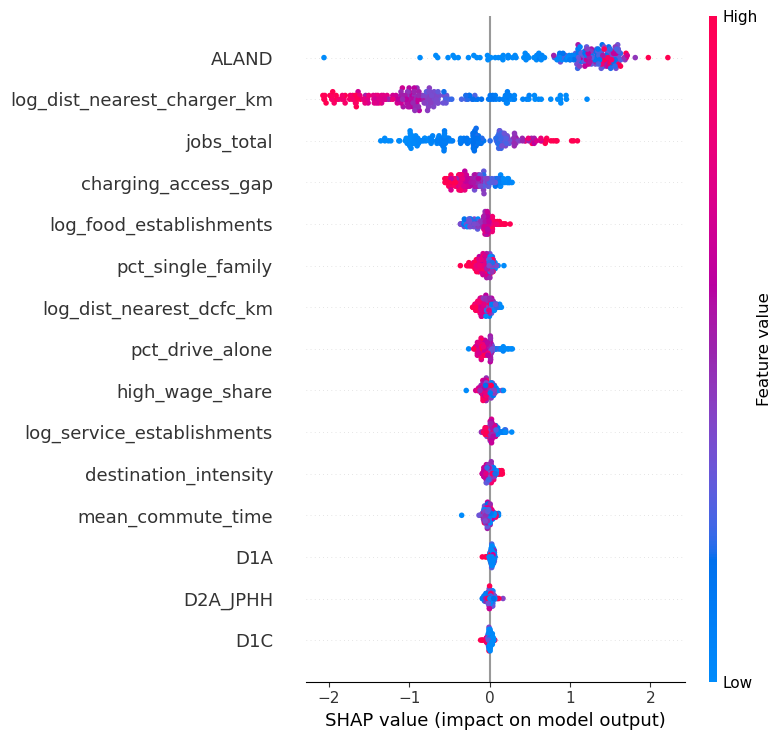

In [8]:
shap.summary_plot(shap_values, X_sample)

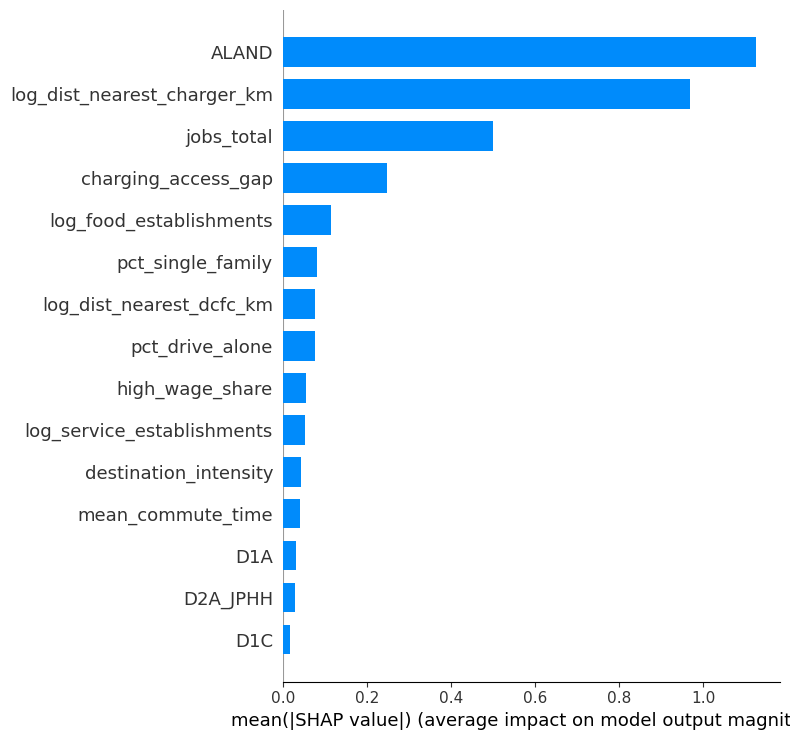

In [9]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

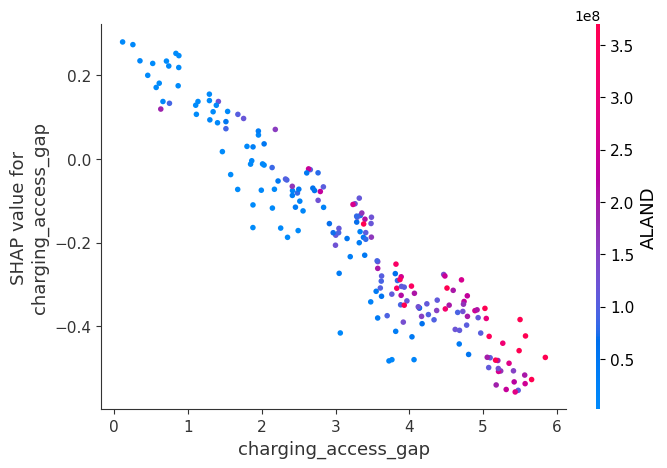

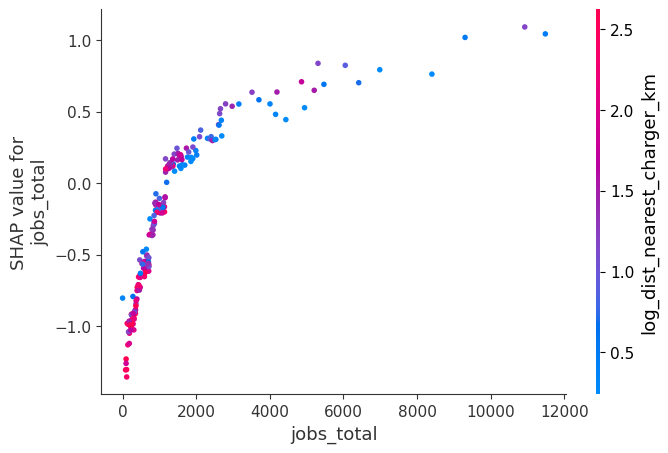

In [10]:
shap.dependence_plot("charging_access_gap", shap_values, X_sample)
shap.dependence_plot("jobs_total", shap_values, X_sample)

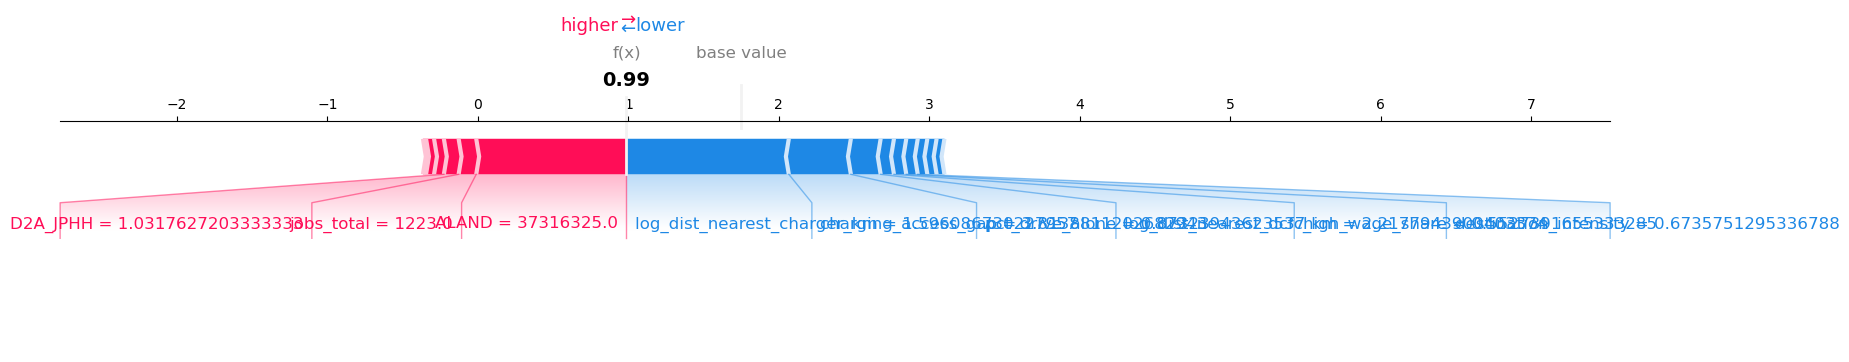

In [11]:
i = 25

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_sample.iloc[i],
    matplotlib=True
)

In [12]:
importance = pd.DataFrame({
    "feature": X_sample.columns,
    "importance": np.abs(shap_values).mean(axis=0)
}).sort_values("importance", ascending=False)

importance

,feature,importance
3,ALAND,1.126228
2,log_dist_nearest_charger_km,0.968963
0,jobs_total,0.500941
4,charging_access_gap,0.248739
10,log_food_establishments,0.115696
14,pct_single_family,0.080646
5,log_dist_nearest_dcfc_km,0.075800
13,pct_drive_alone,0.075694
8,high_wage_share,0.054816
11,log_service_establishments,0.052121


# FOR CA

In [13]:
state = "CA"

file_path = f"prediction_data/predicted/ev_master_{state}_with_predictions.geojson"
gdf = gpd.read_file(file_path)

print("Rows:", len(gdf))

Rows: 9129


In [14]:
gdf = create_features(gdf)

top_features = [
    "jobs_total",
    "destination_intensity",
    "log_dist_nearest_charger_km",
    "ALAND",
    "charging_access_gap",
    "log_dist_nearest_dcfc_km",
    "mean_commute_time",
    "D1A",
    "high_wage_share",
    "D1C",
    "log_food_establishments",
    "log_service_establishments",
    "D2A_JPHH",
    "pct_drive_alone",
    "pct_single_family"
]

X = gdf[top_features]

In [15]:
X_sample = X
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

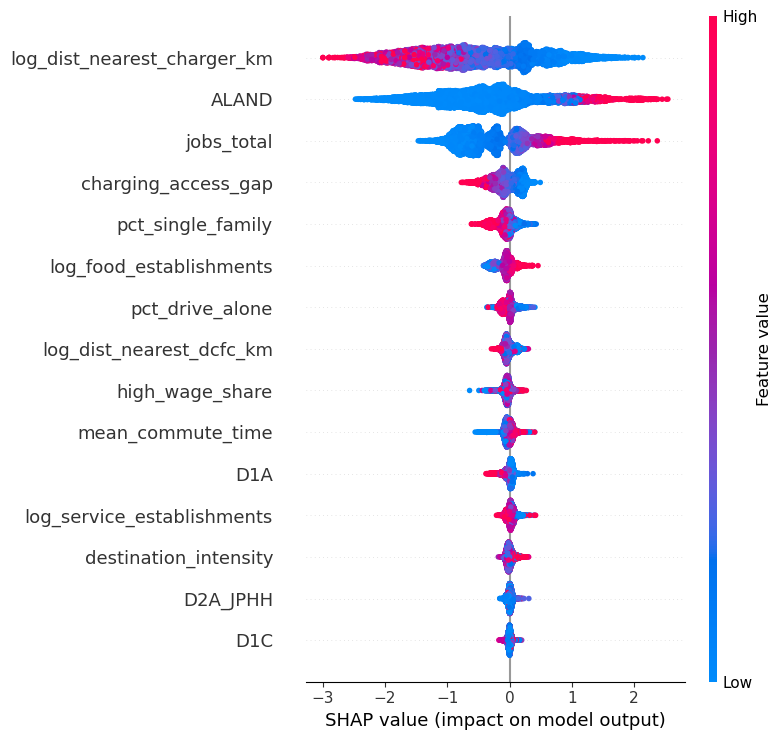

In [16]:
shap.summary_plot(shap_values, X_sample)

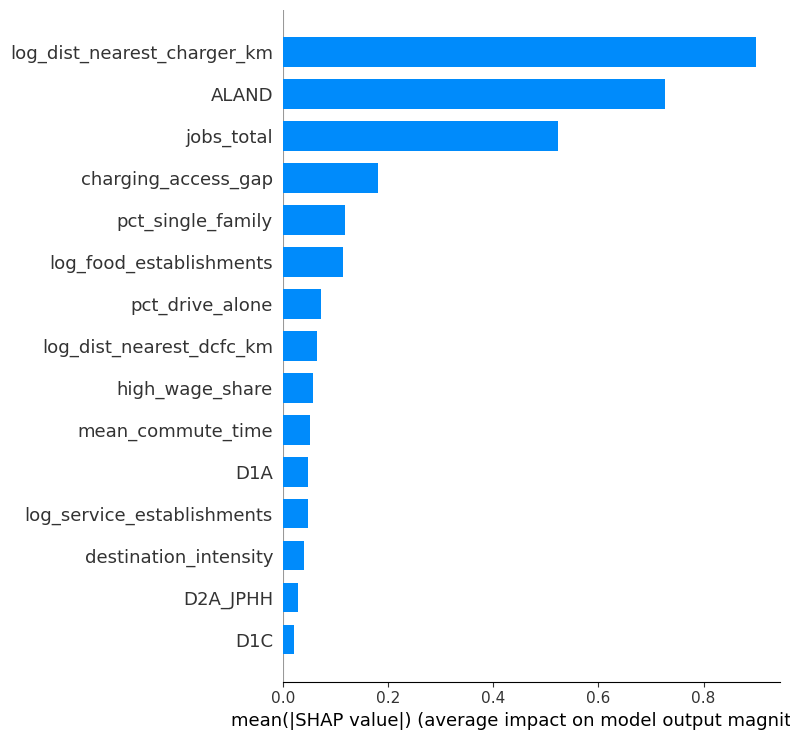

In [17]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

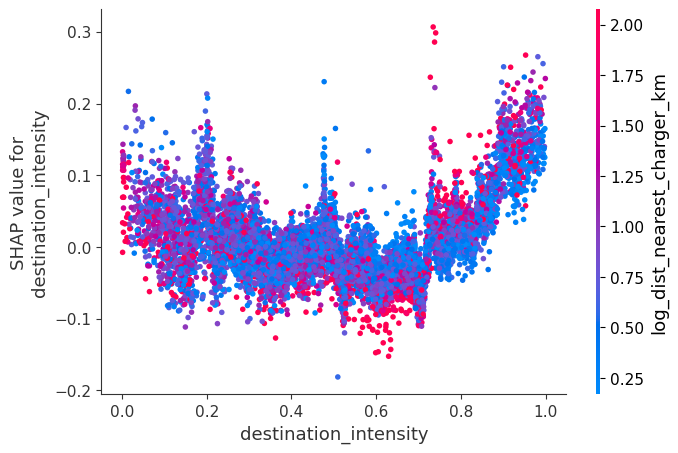

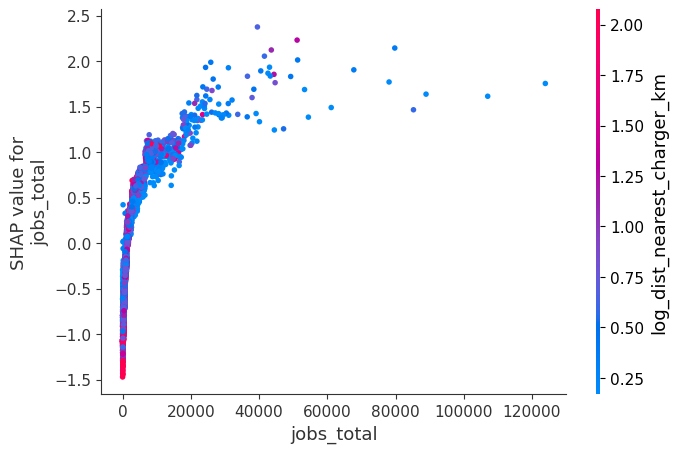

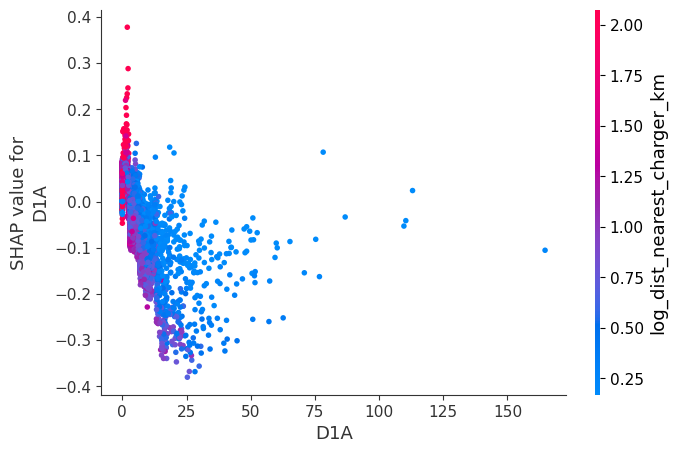

In [18]:
shap.dependence_plot("destination_intensity", shap_values, X_sample)
shap.dependence_plot("jobs_total", shap_values, X_sample)
shap.dependence_plot("D1A", shap_values, X_sample)